# 10 — Results Aggregation & Analysis

Pulls together every arm's results (as written by the executed pipeline) and produces the
project's headline deliverables: the **data-efficiency curve** (F1 vs annotation budget, per
method per domain) and the **cost-performance analysis**, plus a **per-entity-type breakdown**
to test the hypothesis that LLM prompting holds up on generic types (person, location) but
struggles on domain-specific ones (SciERC Method/Task, WNUT creative-work).

Reads the real files produced upstream:
- `results/baseline_results.json`               — NB04 (in-domain F1 + zero-shot degradation)
- `results/fewshot/fewshot_results.csv`         — NB05, Arm 1 (few-shot fine-tune)
- `results/mitigated/mitigated_results.csv`     — NB06, Arm 1 mitigated (optional)
- `results/dap_fewshot/dap_fewshot_results.csv` — NB08, Arm 2 (DAP + few-shot)
- `results/llm_prompting/llm_prompting_results.csv` — NB09, Arm 3 (LLM prompting)
- `results/dap_training_info.json`              — NB07 (DAP wall-clock, for cost amortization)

The primary comparison metric is **typed micro-F1** on the target test set (the same
`test_typed_f1` column every arm now writes). Missing arms are skipped with a warning.

In [1]:
!pip -q install pandas matplotlib seaborn

## Step 1 — Mount Drive, load every arm

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import json
from pathlib import Path

PROCESSED      = Path('/content/drive/MyDrive/AAI590/data/processed')
LABELS_DIR     = PROCESSED / 'label_maps'
MODELS_DIR     = PROCESSED / 'models'
RESULTS_DIR    = PROCESSED / 'results'
FEWSHOT_SPLITS = PROCESSED / 'fewshot_splits'

TARGET_DATASETS = ['wnut17', 'scierc']
BUDGETS = [50, 100, 200]
SEEDS   = [13, 42, 101]

def load_jsonl(path):
    rows = []
    with open(path) as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

METHOD_LABELS = {
    'fewshot':      'Few-shot fine-tune (Arm 1)',
    'mitigated':    'Mitigated few-shot ablation (retuned)',
    'dap_fewshot':  'DAP + few-shot (Arm 2)',
    'llm_prompting':'LLM prompting (Arm 3)',
    'llm_retrieval':'LLM prompting + retrieval (Arm 3b, NB09c)',
}

def load_csv(path, method):
    if not Path(path).exists():
        print(f'WARNING: {path.name} not found -- {method} omitted'); return None
    df = pd.read_csv(path)
    df['method'] = method
    return df

baseline = None
bpath = RESULTS_DIR / 'baseline_results.json'
if bpath.exists():
    baseline = json.load(open(bpath))
else:
    print('WARNING: baseline_results.json not found -- zero-shot reference omitted')

arm1 = load_csv(RESULTS_DIR / 'fewshot_v2' / 'fewshot_results.csv', 'fewshot')  # fixed budget-scaled version
arm1b = load_csv(RESULTS_DIR / 'mitigated_retuned' / 'mitigated_results.csv', 'mitigated')
arm2 = load_csv(RESULTS_DIR / 'dap_fewshot' / 'dap_fewshot_results.csv', 'dap_fewshot')
arm3 = load_csv(RESULTS_DIR / 'llm_prompting' / 'llm_prompting_results.csv', 'llm_prompting')
arm3b = load_csv(RESULTS_DIR / 'llm_prompting' / 'llm_retrieval_results.csv', 'llm_retrieval')  # NB09c
dap_info = json.load(open(RESULTS_DIR / 'dap_training_info.json')) if (RESULTS_DIR / 'dap_training_info.json').exists() else None

## Step 2 — Unify into one long table

Every arm now writes `test_typed_f1` / `test_boundary_f1` / `per_type`. We normalize the few
columns that differ (cost/time is GPU-seconds for the fine-tuning arms, USD for the API arm),
and record `n_eval` so the eval sets can be checked for consistency.

In [4]:
KEEP = ['method', 'dataset', 'budget', 'seed', 'test_typed_f1', 'test_boundary_f1', 'per_type']

frames = []
for df in [arm1, arm1b, arm2, arm3, arm3b]:
    if df is None:
        continue
    d = df.copy()
    for c in KEEP:
        if c not in d.columns:
            d[c] = None
    d = d[KEEP].copy()
    # cost/time column
    if 'cost_usd' in df.columns:      # arm 3
        d['cost_usd'] = df['cost_usd']
        d['train_seconds'] = None
    else:
        d['cost_usd'] = None
        d['train_seconds'] = df['train_seconds'] if 'train_seconds' in df.columns else None
    d['n_eval'] = df['n_eval'] if 'n_eval' in df.columns else None
    frames.append(d)

combined = pd.concat(frames, ignore_index=True)
combined['method_label'] = combined['method'].map(METHOD_LABELS)
combined.drop(columns=['per_type']).to_csv(RESULTS_DIR / 'combined_results.csv', index=False)

# eval-set consistency check (full-test fine-tuning arms have no n_eval column; LLM records it)
n_eval_seen = combined.dropna(subset=['n_eval']).groupby('dataset')['n_eval'].unique()
for ds, vals in n_eval_seen.items():
    if len(vals) > 1:
        print(f'WARNING: {ds} evaluated on different sentence counts across arms: {vals} '
              '-- three-way comparison is only valid on a common eval set.')
print('methods present:', sorted(combined['method'].dropna().unique()))
display(combined.drop(columns=['per_type']).head())

methods present: ['dap_fewshot', 'fewshot', 'llm_prompting', 'llm_retrieval', 'mitigated']


/tmp/ipykernel_1105/3602102938.py:22: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True)


,method,dataset,budget,seed,test_typed_f1,test_boundary_f1,cost_usd,train_seconds,n_eval,method_label
0,fewshot,scierc,50,13,0.200686,0.504555,NaN,NaN,None,Few-shot fine-tune (Arm 1)
1,fewshot,scierc,50,42,0.246279,0.537065,NaN,NaN,None,Few-shot fine-tune (Arm 1)
2,fewshot,scierc,50,101,0.270313,0.551098,NaN,NaN,None,Few-shot fine-tune (Arm 1)
3,fewshot,scierc,100,13,0.295213,0.554791,NaN,NaN,None,Few-shot fine-tune (Arm 1)
4,fewshot,scierc,100,42,0.327310,0.586744,NaN,NaN,None,Few-shot fine-tune (Arm 1)


## Step 3 — Data-efficiency curve (typed F1 vs budget)

One line per method, one panel per target domain. Fine-tuning arms show mean ± std across the
three seeds; the LLM arm is a single-seed point estimate (no band). The zero-shot baseline is
drawn as a dashed reference — note it is a *boundary*-only number (the CoNLL head cannot emit
target types), so it is not directly comparable to the typed curves and is shown for context.

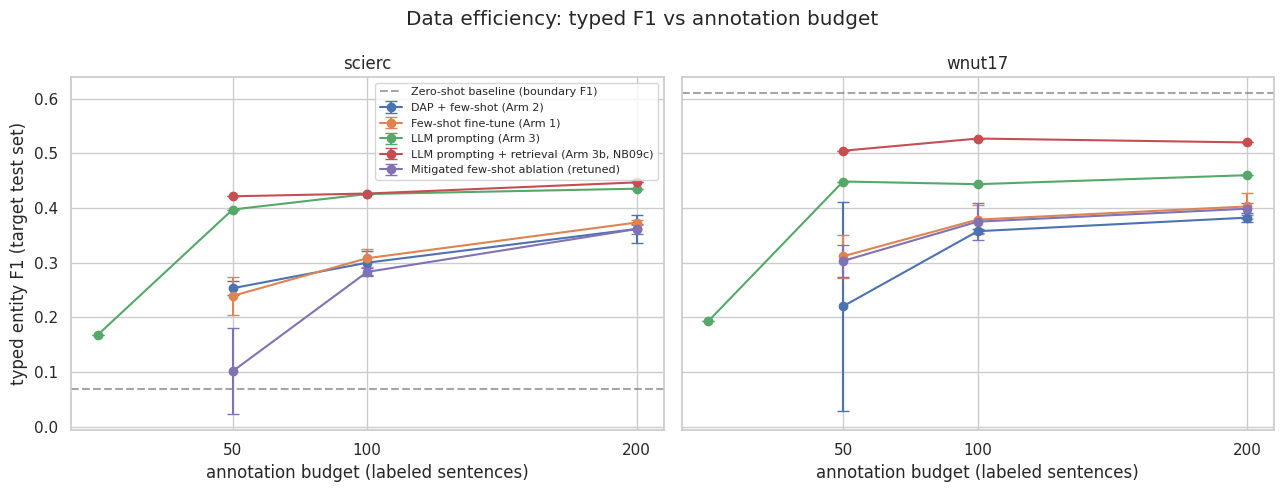

,dataset,method,method_label,budget,f1_mean,f1_std,n
0,scierc,dap_fewshot,DAP + few-shot (Arm 2),50,0.253,0.013,3
1,scierc,dap_fewshot,DAP + few-shot (Arm 2),100,0.300,0.022,3
2,scierc,dap_fewshot,DAP + few-shot (Arm 2),200,0.362,0.026,3
3,scierc,fewshot,Few-shot fine-tune (Arm 1),50,0.239,0.035,3
4,scierc,fewshot,Few-shot fine-tune (Arm 1),100,0.308,0.017,3
5,scierc,fewshot,Few-shot fine-tune (Arm 1),200,0.373,0.005,3
6,scierc,llm_prompting,LLM prompting (Arm 3),0,0.168,0.000,1
7,scierc,llm_prompting,LLM prompting (Arm 3),50,0.397,0.000,1
8,scierc,llm_prompting,LLM prompting (Arm 3),100,0.425,0.000,1
9,scierc,llm_prompting,LLM prompting (Arm 3),200,0.435,0.000,1


In [5]:
agg = (combined.groupby(['dataset', 'method', 'method_label', 'budget'], as_index=False)
       .agg(f1_mean=('test_typed_f1', 'mean'), f1_std=('test_typed_f1', 'std'), n=('test_typed_f1', 'count')))
agg['f1_std'] = agg['f1_std'].fillna(0.0)

datasets = sorted(combined['dataset'].dropna().unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(6.5 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    for label, sub in agg[agg['dataset'] == ds].groupby('method_label'):
        sub = sub.sort_values('budget')
        ax.errorbar(sub['budget'], sub['f1_mean'], yerr=sub['f1_std'], marker='o', capsize=4, label=label)
    if baseline is not None:
        zs = baseline.get('zero_shot_cross_domain_boundary_f1', {}).get(ds, {}).get('f1')
        if zs is not None:
            ax.axhline(zs, ls='--', color='gray', alpha=0.7, label='Zero-shot baseline (boundary F1)')
    ax.set_title(ds); ax.set_xlabel('annotation budget (labeled sentences)'); ax.set_xticks(BUDGETS)
axes[0].set_ylabel('typed entity F1 (target test set)')
axes[0].legend(fontsize=8)
fig.suptitle('Data efficiency: typed F1 vs annotation budget')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'data_efficiency_curve.png', dpi=150, bbox_inches='tight')
plt.show()
display(agg.round(3))

## Step 4 — Cost-performance

The arms have no native common cost unit: fine-tuning costs GPU wall-clock; the LLM arm costs
API dollars. To place them on one axis, GPU time is converted at a rough **$0.20/GPU-hour**
(order-of-magnitude only). Arm 2 carries its share of the one-off DAP pretraining from NB07
(paid once per domain, reused by all 9 budget×seed runs → 1/9 per run).

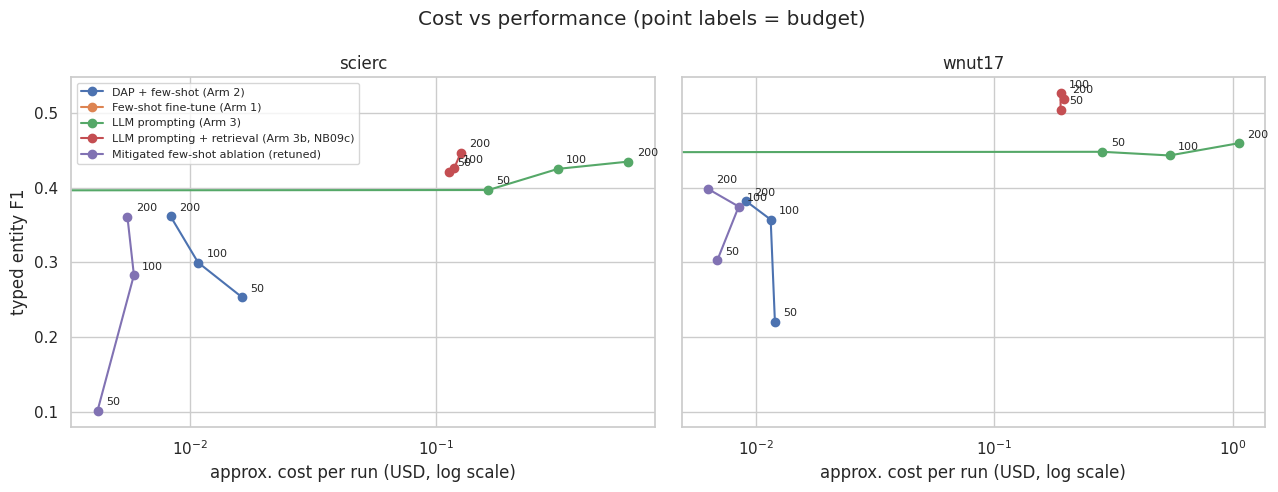

,dataset,method_label,budget,f1_mean,cost_mean
0,scierc,DAP + few-shot (Arm 2),50,0.2531,0.0163
1,scierc,DAP + few-shot (Arm 2),100,0.2999,0.0108
2,scierc,DAP + few-shot (Arm 2),200,0.3616,0.0083
3,scierc,Few-shot fine-tune (Arm 1),50,0.2391,0.0000
4,scierc,Few-shot fine-tune (Arm 1),100,0.3081,0.0000
5,scierc,Few-shot fine-tune (Arm 1),200,0.3732,0.0000
6,scierc,LLM prompting (Arm 3),0,0.1681,0.0000
7,scierc,LLM prompting (Arm 3),50,0.3971,0.1636
8,scierc,LLM prompting (Arm 3),100,0.4254,0.3140
9,scierc,LLM prompting (Arm 3),200,0.4352,0.6072


In [6]:
GPU_HOUR_USD = 0.20

dap_share = {}
if dap_info is not None:
    for ds, info in dap_info.items():
        dap_share[ds] = info['train_seconds'] / 9.0

def approx_cost_usd(row):
    if pd.notna(row['cost_usd']):
        return row['cost_usd']                       # arm 3 (API dollars)
    secs = row['train_seconds'] if pd.notna(row['train_seconds']) else 0.0
    if row['method'] == 'dap_fewshot':
        secs += dap_share.get(row['dataset'], 0.0)
    return secs / 3600.0 * GPU_HOUR_USD

combined['approx_cost_usd'] = combined.apply(approx_cost_usd, axis=1)
cost_agg = (combined.groupby(['dataset', 'method_label', 'budget'], as_index=False)
            .agg(f1_mean=('test_typed_f1', 'mean'), cost_mean=('approx_cost_usd', 'mean')))

fig, axes = plt.subplots(1, len(datasets), figsize=(6.5 * len(datasets), 5), sharey=True)
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    for label, sub in cost_agg[cost_agg['dataset'] == ds].groupby('method_label'):
        sub = sub.sort_values('budget')
        ax.plot(sub['cost_mean'], sub['f1_mean'], marker='o', label=label)
        for _, r in sub.iterrows():
            if r['cost_mean'] > 0:
                ax.annotate(int(r['budget']), (r['cost_mean'], r['f1_mean']),
                            textcoords='offset points', xytext=(6, 4), fontsize=8)
    ax.set_xscale('log'); ax.set_title(ds); ax.set_xlabel('approx. cost per run (USD, log scale)')
axes[0].set_ylabel('typed entity F1'); axes[0].legend(fontsize=8)
fig.suptitle('Cost vs performance (point labels = budget)')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'cost_performance.png', dpi=150, bbox_inches='tight')
plt.show()
display(cost_agg.round(4))

## Step 5 — Per-entity-type breakdown (budget 200)

Per-type F1 at the largest budget, averaged across seeds for the fine-tuning arms. This is the
direct test of the generic-vs-domain-specific hypothesis. Arms without a `per_type` column are
skipped (re-run NB05/06 after the per-type patch to include Arm 1 here).

In [7]:
BREAKDOWN_BUDGET = 200
rows = []
for _, r in combined[combined['budget'] == BREAKDOWN_BUDGET].iterrows():
    if not isinstance(r['per_type'], str):
        continue
    try:
        pt = json.loads(r['per_type'])
    except Exception:
        continue
    for etype, m in pt.items():
        rows.append({'dataset': r['dataset'], 'method_label': r['method_label'],
                     'entity_type': etype, 'f1': m['f1'], 'support': m['support']})

if rows:
    per_type_df = pd.DataFrame(rows)
    for ds in datasets:
        sub = per_type_df[per_type_df['dataset'] == ds]
        if sub.empty:
            continue
        table = (sub.groupby(['entity_type', 'method_label'], as_index=False)
                 .agg(f1=('f1', 'mean'), support=('support', 'max'))
                 .pivot(index=['entity_type', 'support'], columns='method_label', values='f1').round(3))
        print(f'\n=== {ds} -- per-type F1 at budget {BREAKDOWN_BUDGET} ===')
        display(table)
        table.to_csv(RESULTS_DIR / f'per_type_f1_{ds}.csv')
else:
    print('No per_type data found. Re-run NB05/06/08/09 (they now emit per_type).')


=== scierc -- per-type F1 at budget 200 ===


,method_label,DAP + few-shot (Arm 2),LLM prompting (Arm 3),"LLM prompting + retrieval (Arm 3b, NB09c)",Mitigated few-shot ablation (retuned)
entity_type,support,,,,
Generic,241,0.589,0.330,0.355,0.550
Material,158,0.131,0.355,0.374,0.142
Method,430,0.441,0.553,0.569,0.467
Metric,71,0.016,0.410,0.400,0.000
OtherScientificTerm,520,0.327,0.405,0.409,0.317
Task,263,0.255,0.453,0.482,0.278



=== wnut17 -- per-type F1 at budget 200 ===


,method_label,DAP + few-shot (Arm 2),LLM prompting (Arm 3),"LLM prompting + retrieval (Arm 3b, NB09c)",Mitigated few-shot ablation (retuned)
entity_type,support,,,,
corporation,66,0.149,0.411,0.467,0.169
creative-work,142,0.202,0.453,0.460,0.256
group,165,0.237,0.246,0.342,0.246
location,150,0.408,0.555,0.625,0.407
person,429,0.628,0.556,0.627,0.624
product,127,0.012,0.272,0.314,0.043


## Step 6 — Summary table + baseline degradation narrative

In [8]:
summary = (combined.groupby(['dataset', 'method_label', 'budget'])
           .agg(typed_f1_mean=('test_typed_f1', 'mean'), typed_f1_std=('test_typed_f1', 'std'),
                cost_usd=('approx_cost_usd', 'mean'), runs=('test_typed_f1', 'count'))
           .round(4).reset_index())
summary.to_csv(RESULTS_DIR / 'summary_typed_f1_by_method_budget.csv', index=False)
display(summary)

if baseline is not None:
    ind = baseline.get('in_domain_conll2003_test', {})
    f1 = ind.get('eval_f1') or ind.get('f1')
    print('\nCoNLL baseline in-domain test F1:', round(f1, 3) if f1 else 'n/a')
    print('Zero-shot cross-domain boundary F1 (CoNLL-trained baseline):')
    for ds, m in baseline.get('zero_shot_cross_domain_boundary_f1', {}).items():
        print(f'  {ds}: {m["f1"]:.3f}')
print('\nSaved: combined_results.csv, summary_typed_f1_by_method_budget.csv, '
      'data_efficiency_curve.png, cost_performance.png, per_type_f1_*.csv')

,dataset,method_label,budget,typed_f1_mean,typed_f1_std,cost_usd,runs
0,scierc,DAP + few-shot (Arm 2),50,0.2531,0.0125,0.0163,3
1,scierc,DAP + few-shot (Arm 2),100,0.2999,0.0217,0.0108,3
2,scierc,DAP + few-shot (Arm 2),200,0.3616,0.0262,0.0083,3
3,scierc,Few-shot fine-tune (Arm 1),50,0.2391,0.0354,0.0000,3
4,scierc,Few-shot fine-tune (Arm 1),100,0.3081,0.0170,0.0000,3
5,scierc,Few-shot fine-tune (Arm 1),200,0.3732,0.0051,0.0000,3
6,scierc,LLM prompting (Arm 3),0,0.1681,NaN,0.0000,1
7,scierc,LLM prompting (Arm 3),50,0.3971,NaN,0.1636,1
8,scierc,LLM prompting (Arm 3),100,0.4254,NaN,0.3140,1
9,scierc,LLM prompting (Arm 3),200,0.4352,NaN,0.6072,1



CoNLL baseline in-domain test F1: 0.91
Zero-shot cross-domain boundary F1 (CoNLL-trained baseline):
  wnut17: 0.610
  scierc: 0.068

Saved: combined_results.csv, summary_typed_f1_by_method_budget.csv, data_efficiency_curve.png, cost_performance.png, per_type_f1_*.csv


**Reading the results:** the Arm 2 − Arm 1 gap is the DAP hypothesis test; each curve's slope
says how much an extra labeled example buys; the LLM line's height says whether zero-training
prompting is a viable budget alternative per domain, and the per-type table says whether it is
competitive everywhere or only on generic types.